<a href="https://colab.research.google.com/github/Lourdes-Churacutipa/Repositorio-de-lourdes/blob/main/Lab5_2_griddata_netcdf_Peru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Datos Gridded y NetCDF – Análisis Climático del Perú
## Ciencia de Datos Ambientales

**Tema:** ¿Cómo trabajamos con datos ambientales espacialmente continuos como clima, temperatura y precipitación?

**Duración:** 75 minutos

**Objetivos de aprendizaje:**
- Comprender la estructura y propósito de los datos gridded ambientales
- Trabajar con sistemas de referencia de coordenadas para datos espaciales
- Leer y explorar archivos NetCDF usando **xarray**
- Realizar **agregación** espacial y temporal sobre datos climáticos
- Dibujar mapas de calidad de publicación usando **cartopy**
- Calcular anomalías climáticas respecto a un período de referencia

**Datos:** Dataset climático del Perú PISCO/CRU TS (1991–2024)
- Cobertura: todo el territorio peruano
- Latitud: 0.25°S a 18.25°S
- Longitud: 68.25°O a 81.25°O
- Resolución: 0.5° × 0.5°
- Temporal: mensual

---

In [ ]:
# Instalar paquetes necesarios (ejecutar una vez si no están instalados)
!pip install xarray netCDF4 pyproj cartopy -q

# Para Google Colab
- Conectar tu Google Drive.

In [ ]:
# Mount Google Drive (the NetCDF file is stored there)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Importaciones estándar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

import warnings
warnings.filterwarnings('ignore')

---
## 1. Introducción a los Datos Gridded

### ¿Por qué datos gridded?

Variables ambientales como temperatura, precipitación y viento son **espacialmente continuas** — existen en todas partes, no solo en estaciones de medición. Los datos gridded representan estos campos continuos como valores en una cuadrícula regular.

### Fuentes de datos gridded ambientales

| Tipo de fuente | Descripción | Ejemplos |
|----------------|-------------|----------|
| **Reanálisis** | Combina observaciones con modelos para registros históricos consistentes | ERA5, MERRA-2, NCEP/NCAR |
| **Modelos climáticos** | Simulaciones de clima pasado, presente o futuro | CMIP6, CESM, GFDL |
| **Productos satelitales** | Derivados de teledetección | MODIS LST, CHIRPS precipitación, SMAP humedad de suelo |
| **Observaciones interpoladas** | Datos de estaciones interpolados a una cuadrícula | **CRU TS**, PISCO (Perú), SENAMHI-gridded |

### Datos usados hoy: Dataset Climático del Perú (CRU TS / PISCO)

El dataset simulado cubre el territorio peruano con:
- **Resolución:** 0.5° × 0.5° (~55 km)
- **Período:** 1991–2024 (datos mensuales)
- **Variables:** temperatura media (°C), precipitación (mm/mes)
- **Regiones:** Costa, Sierra y Selva con patrones climáticos realistas

### Estructura de la cuadrícula

Los datos gridded se organizan en **dimensiones**:

- **Latitud** (y): posición Norte–Sur
- **Longitud** (x): posición Este–Oeste
- **Tiempo**: cuándo aplica la observación/simulación

### Consideraciones de resolución

**Resolución espacial:** Tamaño de cada celda de la cuadrícula
- Alta resolución (ej. 1 km): más detalle, archivos más grandes
- Baja resolución (ej. 100 km): menos detalle, más fácil de procesar

**Resolución temporal:** Con qué frecuencia se registran datos
- Horaria: pronósticos del tiempo, análisis de eventos
- Diaria: aplicaciones agrícolas y ecológicas
- Mensual: estudios climáticos, tendencias a largo plazo

**Compromiso:** Mayor resolución = más almacenamiento y cómputo, pero mejor representación local.

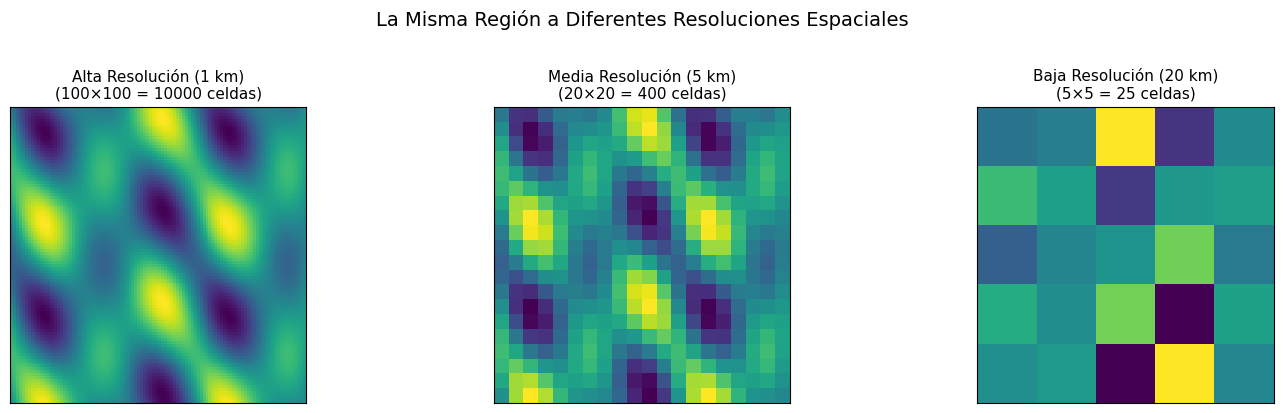

In [ ]:
# Visualizar diferencias de resolución
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))

np.random.seed(123)

resoluciones = [100, 20, 5]
titulos = ['Alta Resolución (1 km)', 'Media Resolución (5 km)', 'Baja Resolución (20 km)']

for ax, res, titulo in zip(ejes, resoluciones, titulos):
    x = np.linspace(0, 10, res)
    y = np.linspace(0, 10, res)
    X, Y = np.meshgrid(x, y)
    Z = np.sin(X) * np.cos(Y) + 0.5 * np.sin(2*X + Y)
    ax.pcolormesh(x, y, Z, cmap='viridis', shading='auto') #RdYlBu_r
    ax.set_title(f'{titulo}\n({res}×{res} = {res**2} celdas)', fontsize=11)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('La Misma Región a Diferentes Resoluciones Espaciales', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Sistemas de Referencia de Coordenadas (CRS)

Un **Sistema de Referencia de Coordenadas (CRS)** define cómo las coordenadas se relacionan con ubicaciones en la Tierra.

### CRS Geográfico (no proyectado)

- Usa **latitud** y **longitud** (grados)
- Basado en un modelo 3D de la Tierra (elipsoide)
- El más común: **WGS84** (EPSG:4326) — usado por GPS
- Distancias y áreas están distorsionadas (1° longitud ≠ la misma distancia en todos lados)

### CRS Proyectado

- Transforma la Tierra 3D a una superficie 2D plana
- Unidades típicamente en metros
- Ejemplos comunes:
  - **UTM (Transverse Mercator Universal)**: Bueno para análisis regional (18S: EPSG:32718)
  - **Albers de Área Igual**: Preserva áreas, bueno para mapas continentales
  - **Lambert Conforme Cónico**: Común para mapas meteorológicos

### El Problema: La Tierra es una Esfera, los Mapas son Planos

Cualquier mapa plano **distorsiona** la Tierra de alguna manera. Diferentes proyecciones preservan diferentes propiedades:

| Tipo de proyección | Preserva | Distorsiona | Uso |
|--------------------|----------|-------------|-----|
| Conforme | Formas (ángulos) | Áreas | Navegación, mapas meteorológicos |
| Área igual | Áreas | Formas | Mapas temáticos, densidad |
| Equidistante | Distancias desde el centro | Áreas, formas | Mediciones de distancia |
| Compromiso | Nada perfectamente | Todo un poco | Mapas de referencia general |

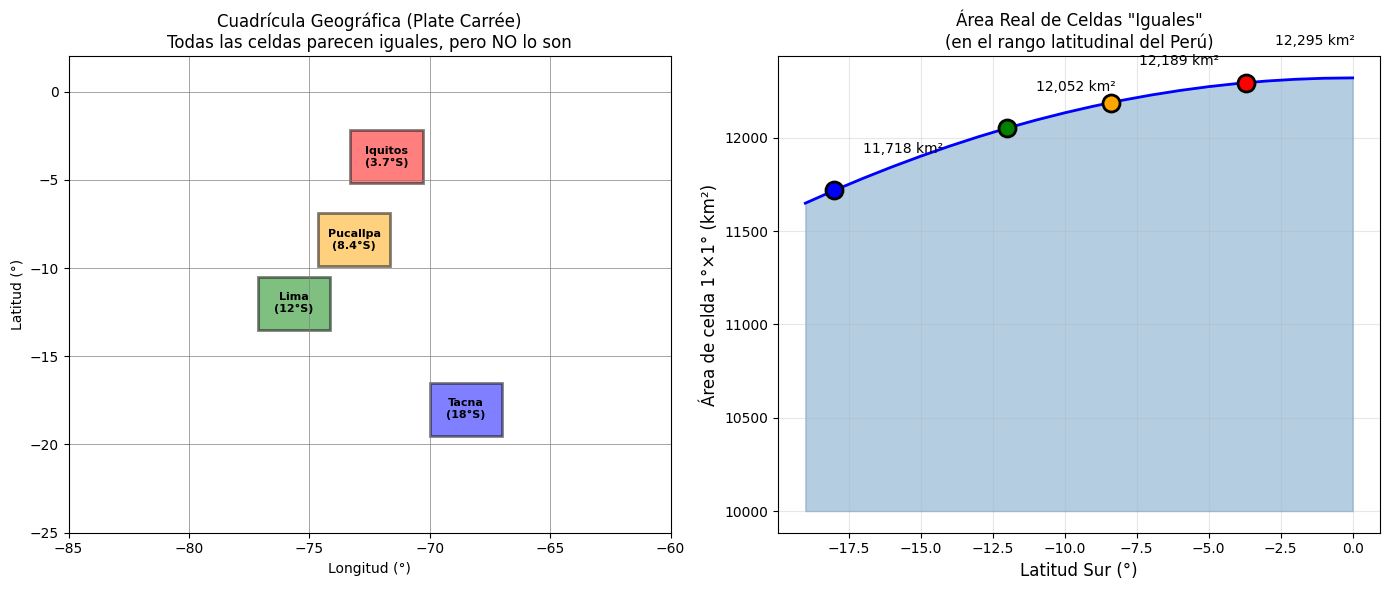

Celda 1°×1° en el ecuador:   ~12,321 km²
Celda 1°×1° a 15.8°S (Puno):   ~11,855 km² (96% del ecuador)


In [ ]:
# Visualizar cómo varía el área de celda con la latitud en coordenadas geográficas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Izquierda: Celdas de igual tamaño en grados parecen iguales en el papel
ax1 = axes[0]
lats = np.arange(-20, 5, 5)    # Rango para el Perú
lons = np.arange(-85, -65, 5)

for lat in np.arange(-25, 5, 5):
    ax1.axhline(lat, color='gray', linewidth=0.5)
for lon in np.arange(-85, -60, 5):
    ax1.axvline(lon, color='gray', linewidth=0.5)

ax1.set_xlim(-85, -60)
ax1.set_ylim(-25, 2)
ax1.set_xlabel('Longitud (°)')
ax1.set_ylabel('Latitud (°)')
ax1.set_title('Cuadrícula Geográfica (Plate Carrée)\nTodas las celdas parecen iguales, pero NO lo son', fontsize=12)

# Marcar celdas en distintas latitudes
from matplotlib.patches import Rectangle
colores_cel = ['red', 'orange', 'green', 'blue']
lats_dest = [-3.7, -8.4, -12, -18]  # Iquitos, Pucallpa, Lima, Tacna
long_dest = [-73.3, -74.64, -77.15, -70]  # Longitud fija para marcar las celdas

nombres_dest = ['Iquitos\n(3.7°S)', 'Pucallpa\n(8.4°S)', 'Lima\n(12°S)', 'Tacna\n(18°S)']
for lat, long, color, nombre in zip(lats_dest, long_dest, colores_cel, nombres_dest):
    rect = Rectangle((long, lat - 1.5), 3, 3, fill=True, facecolor=color, # resta 1.5 para centrar la celda en la latitud
                     alpha=0.5, edgecolor='black', linewidth=2)
    ax1.add_patch(rect)
    ax1.text(long + 1.5, lat, nombre, ha='center', va='center', fontsize=8, fontweight='bold')

# Derecha: Área real de celdas 1°×1° a distintas latitudes (para el Perú)
ax2 = axes[1]
latitudes = np.arange(-19, 1, 1) # Rango de latitudes para el Perú o "latdes"
area_celda = 111 * 111 * np.cos(np.radians(latitudes))  # km²

ax2.fill_between(latitudes, 10000, area_celda, alpha=0.4, color='steelblue')
ax2.plot(latitudes, area_celda, 'b-', linewidth=2)

for lat, color in zip(lats_dest, colores_cel):
    area = 111 * 111 * np.cos(np.radians(lat))
    ax2.scatter([lat], [area], s=150, c=color, edgecolors='black', linewidth=2, zorder=5)
    ax2.annotate(f'{area:,.0f} km²', (lat, area), xytext=(lat+1, area+200), fontsize=10)

ax2.set_xlabel('Latitud Sur (°)', fontsize=12)
ax2.set_ylabel('Área de celda 1°×1° (km²)', fontsize=12)
ax2.set_title('Área Real de Celdas "Iguales"\n(en el rango latitudinal del Perú)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Celda 1°×1° en el ecuador:   ~{111*111:,} km²")
print(f"Celda 1°×1° a 15.8°S (Puno):   ~{111*111*np.cos(np.radians(15.8)):,.0f} km² ({100*np.cos(np.radians(15.8)):.0f}% del ecuador)")

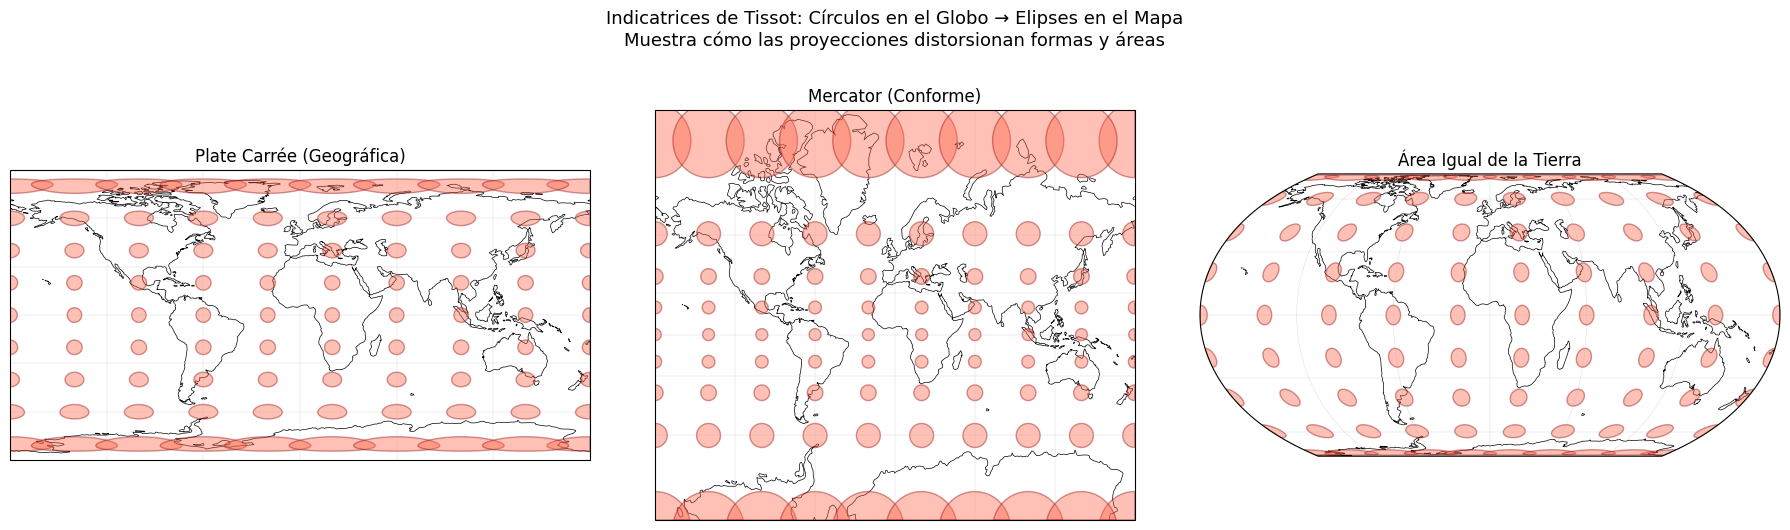

Los círculos rojos tienen el mismo tamaño en la Tierra pero aparecen distorsionados:
  - Plate Carrée:  formas se estiran verticalmente cerca de los polos
  - Mercator:      preserva formas pero infla enormemente las áreas en los polos
  - Área Igual:    preserva áreas pero distorsiona formas


In [ ]:
# Visualizar distorsiones de proyección con indicatrices de Tissot (solo Perú y vecinos)
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(18, 5))

proyecciones = [
    ('Plate Carrée (Geográfica)', ccrs.PlateCarree()),
    ('Mercator (Conforme)', ccrs.Mercator()),
    ('Área Igual de la Tierra', ccrs.EqualEarth())
]

for i, (nombre, proj) in enumerate(proyecciones):
    ax = fig.add_subplot(1, 3, i+1, projection=proj)
    ax.set_global()
    ax.coastlines(linewidth=0.5)
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
    ax.tissot(rad_km=500, lons=np.arange(-180, 180, 40),
              lats=np.arange(-80, 81, 20), alpha=0.4,
              facecolor='tomato', edgecolor='darkred')
    ax.set_title(nombre, fontsize=12)

plt.suptitle("Indicatrices de Tissot: Círculos en el Globo → Elipses en el Mapa\nMuestra cómo las proyecciones distorsionan formas y áreas",
             fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

print("Los círculos rojos tienen el mismo tamaño en la Tierra pero aparecen distorsionados:")
print("  - Plate Carrée:  formas se estiran verticalmente cerca de los polos")
print("  - Mercator:      preserva formas pero infla enormemente las áreas en los polos")
print("  - Área Igual:    preserva áreas pero distorsiona formas")

In [ ]:
from pyproj import CRS, Transformer

# Definir sistemas de referencia de coordenadas
wgs84  = CRS.from_epsg(4326)   # Geográfico (lat/lon)
utm18s = CRS.from_epsg(32718)  # UTM Zona 18S (cubre Lima, Cusco, Madre de Dios)

print("=== WGS84 (Geográfico) ===")
print(f"Nombre: {wgs84.name}")
print(f"Unidades: {wgs84.axis_info[0].unit_name}")
print(f"Tipo: {'Geográfico' if wgs84.is_geographic else 'Proyectado'}")

print("\n=== UTM Zona 18S (Proyectado) ===")
print(f"Nombre: {utm18s.name}")
print(f"Unidades: {utm18s.axis_info[0].unit_name}")
print(f"Tipo: {'Geográfico' if utm18s.is_geographic else 'Proyectado'}")

=== WGS84 (Geográfico) ===
Nombre: WGS 84
Unidades: degree
Tipo: Geográfico

=== UTM Zona 18S (Proyectado) ===
Nombre: WGS 84 / UTM zone 18S
Unidades: metre
Tipo: Proyectado


In [ ]:
# Transformar coordenadas entre CRS
transformer = Transformer.from_crs(wgs84, utm18s, always_xy=True)

# Coordenadas de ciudades peruanas
ciudades_peru = { # creamos un diccionario con las coordenadas de las ciudades
    'Lima':      (-77.04, -12.04),
    'Cusco':     (-71.97, -13.52),
    'Iquitos':   (-73.25,  -3.75),
    'Arequipa':  (-71.54, -16.41),
}

print("Coordenadas en WGS84 y UTM Zona 18S:")
for ciudad, (lon, lat) in ciudades_peru.items():
    x, y = transformer.transform(lon, lat)
    print(f"  {ciudad:12s}: {abs(lat):.2f}°S {abs(lon):.2f}°O  →  E={x:,.0f} m, N={y:,.0f} m")

Coordenadas en WGS84 y UTM Zona 18S:
  Lima        : 12.04°S 77.04°O  →  E=277,917 m, N=8,668,198 m
  Cusco       : 13.52°S 71.97°O  →  E=828,017 m, N=8,503,329 m
  Iquitos     : 3.75°S 73.25°O  →  E=694,347 m, N=9,585,312 m
  Arequipa    : 16.41°S 71.54°O  →  E=869,617 m, N=8,182,556 m


In [ ]:
# Por qué importan las proyecciones: cálculo de distancias
# Distancia Lima – Cusco

lon_l, lat_l = ciudades_peru['Lima']
lon_c, lat_c = ciudades_peru['Cusco']

x_l, y_l = transformer.transform(lon_l, lat_l)
x_c, y_c = transformer.transform(lon_c, lat_c)

distancia_utm = np.sqrt((x_c - x_l)**2 + (y_c - y_l)**2) / 1000 # Convertir a km
distancia_grados = np.sqrt((lon_c - lon_l)**2 + (lat_c - lat_l)**2) # Esto no tiene sentido como distancia real, pero lo calculamos para mostrar la diferencia

print("Distancia Lima → Cusco")
print(f"  Usando UTM (metros): {distancia_utm:.0f} km  ✓ (correcto)")
print(f"  Usando grados:       {distancia_grados:.2f}°   ✗ (sin sentido como distancia)")
lat_media = (lat_l + lat_c) / 2
print(f"\n  Nota 1: 1° de longitud ≈ 111 km en el ecuador, pero solo ~{111 * np.cos(np.radians(43)):.0f} km a 43°N")
print(f"\n  Nota 2: 1° de longitud ≈ 111 km en el ecuador, pero solo ~ {111 * np.cos(np.radians(abs(lat_media))):.0f} km a {abs(lat_media):.0f}°S")

Distancia Lima → Cusco
  Usando UTM (metros): 574 km  ✓ (correcto)
  Usando grados:       5.28°   ✗ (sin sentido como distancia)

  Nota 1: 1° de longitud ≈ 111 km en el ecuador, pero solo ~81 km a 43°N

  Nota 2: 1° de longitud ≈ 111 km en el ecuador, pero solo ~ 108 km a 13°S


### Conclusiones clave sobre CRS

1. **Los datos climáticos/ambientales generalmente vienen en coordenadas geográficas (lat/lon)**
2. **Los cálculos de área necesitan ponderación** por cos(latitud) o proyección apropiada
3. **Al combinar datasets**, asegurarse de que usen el mismo CRS
4. **Para análisis local** (cuencas, departamentos), considerar proyectar a UTM 18S o 19S

---
## 3. Formato NetCDF - Producto global

### ¿Qué es NetCDF?

**NetCDF (Network Common Data Form)** es el formato estándar para datos ambientales gridded.

**Características clave:**
- **Auto-descriptivo**: contiene metadatos que explican el contenido del archivo
- **Multidimensional**: maneja naturalmente arreglos lat × lon × tiempo
- **Eficiente**: almacenamiento comprimido, acceso rápido a subconjuntos
- **Portátil**: funciona en todas las plataformas y lenguajes

### Estructura NetCDF

Nuestro archivo CRU TS4.09 CONUS ([link](https://crudata.uea.ac.uk/cru/data/hrg/cru_ts_4.09/)) tiene esta estructura:

```
NetCDF File
├── Dimensions (define array sizes)
│   ├── time: 1488
│   ├── lat: 50
│   └── lon: 117
├── Variables (the actual data)
│   ├── time(time): datetime values (monthly, mid-month)
│   ├── lat(lat): latitude values (24.75 to 49.25°N)
│   ├── lon(lon): longitude values (-124.75 to -66.75°W)
│   ├── tmp(time, lat, lon): near-surface temperature (°C)
│   ├── stn(time, lat, lon): number of contributing stations
│   ├── mae(time, lat, lon): mean absolute error
│   └── maea(time, lat, lon): MAE anomaly
└── Attributes (metadata)
    ├── title: "CRU TS4.09 Mean Temperature"
    ├── institution: "British Atmospheric Data Centre"
    └── history: "CONUS subset extracted from global file"
```

Tambien trabajaremos con datos de las normales de temperatura de PISCOt v1.2 de SENAMHI ([figshare](https://figshare.com/collections/_/5959863)).

### Convenciones CF

Las **convenciones Climate and Forecast (CF)** estandarizan cómo se describen los datos climáticos:
- Nombres de variables estándar (ej. `air_temperature`, `precipitation_flux`)
- Especificaciones de unidades
- Descripciones de coordenadas

### Descarga de datos:
1. Directamente a Google Colab (facil)
2. Descarga a tu Google Drive (mediano), luego lo vuelves a leer

In [ ]:
# Opción 1: Directamente a Google Colab
import gdown
# https://drive.google.com/file/d/1ySm0zN2xJ53fA8iWSthTsHXbtzJ7nIcu/view?usp=sharing
ncfile = '1ySm0zN2xJ53fA8iWSthTsHXbtzJ7nIcu'
ncname = "cru_ts4.09.1901.2024.tmp.dat.peru.nc"
gdown.download(f"https://drive.google.com/uc?id={ncfile}", ncname, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ySm0zN2xJ53fA8iWSthTsHXbtzJ7nIcu
To: /content/cru_ts4.09.1901.2024.tmp.dat.peru.nc
100%|██████████| 27.3M/27.3M [00:00<00:00, 147MB/s]


'cru_ts4.09.1901.2024.tmp.dat.peru.nc'

In [ ]:
# Opsción 2: Descarga a Drive:
# Si aun no tienes el archivo, puedes descargarlo usando gdown:
# Si estás usando Google Colab, asegúrate de montar tu Google Drive y ajustar la ruta al archivo NetCDF según corresponda
# Link de descarga del NetCDF de CRU TS4.09 (de acceso libre):
# https://drive.google.com/file/d/1ySm0zN2xJ53fA8iWSthTsHXbtzJ7nIcu/view?usp=sharing
# leer desde google drive directo al link:

# import os
# import gdown

# # Crear la carpeta si no existe
# os.makedirs('/content/drive/MyDrive/Ciencias de Datos Ambientales/3_clases/data2', exist_ok=True)
# # Descargar el archivo desde Google Drive
# file_id = '1ySm0zN2xJ53fA8iWSthTsHXbtzJ7nIcu'
# gdown.download(id=file_id, output='/content/drive/MyDrive/Ciencias de Datos Ambientales/3_clases/data2/cru_ts4.09.1901.2024.tmp.dat.peru.nc', quiet=False)


In [ ]:
# Cargar datos de temperatura CRU TS4.09 (subconjunto CONUS, 1901-2024)

# Opción 1:
# Abrir el conjunto de datos
ds = xr.open_dataset(ncname)

# Opción 2:
# cru_path = "/content/drive/MyDrive/Ciencias de Datos Ambientales/3_clases/data/cru_ts4.09.1901.2024.tmp.dat.peru.nc"
# cru_path = "data/cru_ts4.09.1901.2024.tmp.dat.peru.nc" # Yo lo tengo así

# Abrir el conjunto de datos
# ds = xr.open_dataset(cru_path)

print("¡Conjunto de datos de temperatura CRU cargado correctamente!")
ds

¡Conjunto de datos de temperatura CRU cargado correctamente!


<xarray.Dataset> Size: 34MB
Dimensions:  (time: 1488, lat: 39, lon: 29)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1901-01-16 1901-02-15 ... 2024-12-16
  * lat      (lat) float32 156B -18.25 -17.75 -17.25 -16.75 ... -0.25 0.25 0.75
  * lon      (lon) float32 116B -81.25 -80.75 -80.25 ... -68.25 -67.75 -67.25
Data variables:
    tmp      (time, lat, lon) float32 7MB ...
    stn      (time, lat, lon) float64 13MB ...
    mae      (time, lat, lon) float32 7MB ...
    maea     (time, lat, lon) float32 7MB ...
Attributes:
    Conventions:  CF-1.4
    title:        CRU TS4.09 Mean Temperature
    institution:  Data held at British Atmospheric Data Centre, RAL, UK.
    source:       Run ID = 2503051245. Data generated from:tmp.2503051121.dtb
    history:      Wed  5 Mar 13:28:04 GMT 2025 : User f098 : Program makegrid...
    references:   Information on the data is available at http://badc.nerc.ac...
    comment:      Access to these data is available to any registered CEDA user.
    contact:      support@ceda.ac.uk

In [ ]:
# Atributos globales del dataset
print("Atributos del Dataset:")
for attr, valor in ds.attrs.items():
    print(f"  {attr}: {valor}")

Atributos del Dataset:
  Conventions: CF-1.4
  title: CRU TS4.09 Mean Temperature
  institution: Data held at British Atmospheric Data Centre, RAL, UK.
  source: Run ID = 2503051245. Data generated from:tmp.2503051121.dtb
  history: Wed  5 Mar 13:28:04 GMT 2025 : User f098 : Program makegridsauto.for called by update.for
  references: Information on the data is available at http://badc.nerc.ac.uk/data/cru/
  comment: Access to these data is available to any registered CEDA user.
  contact: support@ceda.ac.uk


## Producto peruano: PISCO temperatura

La metadata y data completa se encuentra en el siguiente link [figshare](https://figshare.com/collections/_/5959863).
Ahora leeremos los datos de las normales de temperatura mínima de PISCOt v1.2 de SENAMHI.

- Normal de Temperatura mínima: https://drive.google.com/file/d/1amIGgfYXoxjD4D_3WMR66Mg2TJIZo01z/view?usp=sharing
- Normal de Temperatura máxima: https://drive.google.com/file/d/1BD0e-XfJYXxK0HDkIs2YMBeKPyvF3YJu/view?usp=sharingm

In [ ]:
# # Si lo ejecutas en Colab, puedes descargar el NetCDF de PISCOt 1.2 (Normal Mensual, 1981-2010) desde el enlace:

# import os
# import gdown

# pisco_path = "data/PISCOt v1.2/tmin/tmin_mean_1981-2010.nc"

# # Crear la carpeta si no existe
# os.makedirs('data', exist_ok=True)
# os.makedirs('data/PISCOt v1.2/tmin', exist_ok=True)

# # Descargar a esa ruta
# file_id = '1amIGgfYXoxjD4D_3WMR66Mg2TJIZo01z'
# gdown.download(id=file_id, output='data/PISCOt v1.2/tmin/tmin_mean_1981-2010.nc', quiet=False)

In [ ]:
# Cargar datos de temperatura mínima PISCOt 1.2 (Normal Mensual, 1981-2010)
# pisco_path = "data/PISCOt v1.2/tmin/tmin_mean_1981-2010.nc"
pisco_path = "/content/drive/MyDrive/Ciencias de Datos Ambientales/3_clases/data/PISCOt v1.2/tmin/tmin_mean_1981-2010.nc"
# Abrir el conjunto de datos
ds_pisco = xr.open_dataset(pisco_path)

print("¡Conjunto de datos de temperatura PISCO cargado correctamente!")
ds_pisco

¡Conjunto de datos de temperatura PISCO cargado correctamente!


<xarray.Dataset> Size: 135MB
Dimensions:    (time: 12, latitude: 1982, longitude: 1422)
Coordinates:
  * time       (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude   (latitude) float64 16kB 1.22 1.21 1.2 ... -18.57 -18.58 -18.59
  * longitude  (longitude) float64 11kB -81.4 -81.39 -81.38 ... -67.2 -67.19
Data variables:
    tmin       (time, latitude, longitude) float32 135MB ...
Attributes:
    Variable:  minimum temperature (°C)
    Issues:    https://github.com/adrHuerta/PISCOt_v1-2/issues

In [ ]:
# # 1. Obtener los límites del dataset PISCO
# lat_min, lat_max = ds_pisco.latitude.min(), ds_pisco.latitude.max()
# lon_min, lon_max = ds_pisco.longitude.min(), ds_pisco.longitude.max()

# # 2. Recortar CRU usando esos límites
# # Nota: Si las latitudes de tu archivo están invertidas, usa slice(lat_max, lat_min)
# ds_cru_cut = ds.sel(
#     lat=slice(lat_min, lat_max),
#     lon=slice(lon_min, lon_max)
# )
# # Guardar el subconjunto recortado (opcional)
# ds_cru_cut.to_netcdf("data/cru_ts4.09.1901.2024.tmp.dat.peru.nc")

In [ ]:
# Verificar rango temporal
print(f"Cobertura temporal:")
print(f"  Primer paso: {pd.to_datetime(ds.time.values[0])}")
print(f"  Último paso: {pd.to_datetime(ds.time.values[-1])}")
print(f"  Total meses: {len(ds.time)}")
print(f"  Años cubiertos: {len(ds.time)//12}")

Cobertura temporal:
  Primer paso: 1901-01-16 00:00:00
  Último paso: 2024-12-16 00:00:00
  Total meses: 1488
  Años cubiertos: 124


### Resumen: Leer un archivo NetCDF

En la práctica, cargarías un archivo NetCDF descargado de SENAMHI, ERA5, o CRU TS así:

```python
import xarray as xr

# Abrir dataset NetCDF
ds = xr.open_dataset('/ruta/al/archivo.nc')

# Para múltiples archivos del mismo tipo (ej. un archivo por año):
ds = xr.open_mfdataset('/ruta/datos_*.nc', combine='by_coords')

# Verificar contenido
print(ds)
```

Los archivos NetCDF del Perú están disponibles en:
- **SENAMHI**: https://www.senamhi.gob.pe/
- **ERA5-Land**: https://cds.climate.copernicus.eu/
- **CHIRPS (precipitación)**: https://www.chc.ucsb.edu/data/chirps

---
## 4. Trabajar con xarray

**xarray** extiende los arreglos NumPy con dimensiones y coordenadas etiquetadas, haciéndolo ideal para datos ambientales.

### DataArray vs Dataset

- **DataArray**: una sola variable con coordenadas etiquetadas (ej. `temperatura`)
- **Dataset**: colección de DataArrays con las mismas coordenadas (como un archivo NetCDF)

### Ventajas clave

1. **Dimensiones nombradas**: usa `dim='time'` en vez de `axis=0`
2. **Indexado por coordenadas**: selecciona por valores lat/lon, no índices del arreglo
3. **Alineación automática**: operaciones en datasets con distintas coordenadas se alinean solas
4. **Gráficos integrados**: visualización rápida con `.plot()`

> **Nota:** Nuestro conjunto de datos CRU TS4.09 tiene 4 variables: `tmp` (temperatura), `stn` (número de estaciones), `mae` (error absoluto medio) y `maea` (anomalía del MAE). Nos centraremos en `tmp`.

In [ ]:
# Comprobar la convención de longitud en este conjunto de datos
print(f"Rango de longitud en el conjunto de datos: {float(ds.lon.min()):.1f} a {float(ds.lon.max()):.1f}")

# Determinar si es necesario ajustar para el hemisferio occidental
if float(ds.lon.min()) >= 0:
    print("→ El conjunto de datos utiliza la convención de 0 a 360")
    print("Para seleccionar el hemisferio occidental: sumar 360 a las longitudes negativas")
    print("Ejemplo: Madison a -89.5° → usar 270.5°")
    lon_convention = '0_360'
else:
    print("→ El conjunto de datos utiliza la convención de -180 a 180")
    lon_convention = '-180_180'

Rango de longitud en el conjunto de datos: -81.2 a -67.2
→ El conjunto de datos utiliza la convención de -180 a 180


### 4.1 Seleccionar datos por coordenadas

In [ ]:
# Seleccionar por valor de coordenada exacta
# Obtener la temperatura en Utec, Barranco (ajustar la longitud según la convención)

utec_lat = -12.0747852
utec_lon = -77.1061372 if lon_convention == '-180_180' else 360 - 77.1061372

utec_temp = ds['tmp'].sel(lat=utec_lat, lon=utec_lon, method='nearest')

print(f"Serie temporal de temperatura en Utec, Barranco:")
print(f"Punto de cuadrícula más cercano: {float(utec_temp.lat):.2f}°S, {float(utec_temp.lon):.2f}°O")
print(f"Forma: {utec_temp.shape} (un valor por mes)")
print(f"Primeros 12 valores (1901): {utec_temp.values[:12].round(1)}")

Serie temporal de temperatura en Utec, Barranco:
Punto de cuadrícula más cercano: -12.25°S, -77.25°O
Forma: (1488,) (un valor por mes)
Primeros 12 valores (1901): [21.8 22.9 22.1 20.6 18.7 16.7 15.8 15.8 15.7 16.2 17.3 19.4]


In [ ]:
# Seleccionar por rango de coordenadas (slicing)
# Extraer región amazónica (Loreto)
if lon_convention == '0_360':
    lo_lon_min, lo_lon_max =360-73.0, 360-70.0
else:
    lo_lon_min, lo_lon_max = -73.0, -70.0

loreto = ds['tmp'].sel(
    lat=slice(-6, -2.0), # slice(inicio, fin) depende estrictamente del orden en que los datos están guardados
    lon=slice(lo_lon_min, lo_lon_max)
)
print(f"Subconjunto Loreto (Amazonia):")
print(f"  Rango lat: {float(loreto.lat.min()):.1f}° a {float(loreto.lat.max()):.1f}°")
print(f"  Celdas: {loreto.shape[1]} lat × {loreto.shape[2]} lon")
print(f"  Forma total: {loreto.shape}")

Subconjunto Loreto (Amazonia):
  Rango lat: -5.8° a -2.2°
  Celdas: 8 lat × 6 lon
  Forma total: (1488, 8, 6)


In [ ]:
loreto

<xarray.DataArray 'tmp' (time: 1488, lat: 8, lon: 6)> Size: 286kB
[71424 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 12kB 1901-01-16 1901-02-15 ... 2024-12-16
  * lat      (lat) float32 32B -5.75 -5.25 -4.75 -4.25 -3.75 -3.25 -2.75 -2.25
  * lon      (lon) float32 24B -72.75 -72.25 -71.75 -71.25 -70.75 -70.25
Attributes:
    long_name:                   near-surface temperature
    units:                       degrees Celsius
    correlation_decay_distance:  1200.0

In [ ]:
# Seleccionar por tiempo
# Obtener un único mes
jul_2023 = ds['tmp'].sel(time='2023-07')
print(f"Julio 2023: forma {jul_2023.shape}")

# Obtener un rango de años
reciente = ds['tmp'].sel(time=slice('2015', '2024'))
print(f"2015–2024: forma {reciente.shape}")

# Obtener todos los eneros (mes de lluvias en la Amazonia)
todos_eneros = ds['tmp'].sel(time=ds['tmp'].time.dt.month == 1)
print(f"Todos los Eneros: forma {todos_eneros.shape}")

Julio 2023: forma (1, 39, 29)
2015–2024: forma (120, 39, 29)
Todos los Eneros: forma (124, 39, 29)


### 4.2 Gráficos

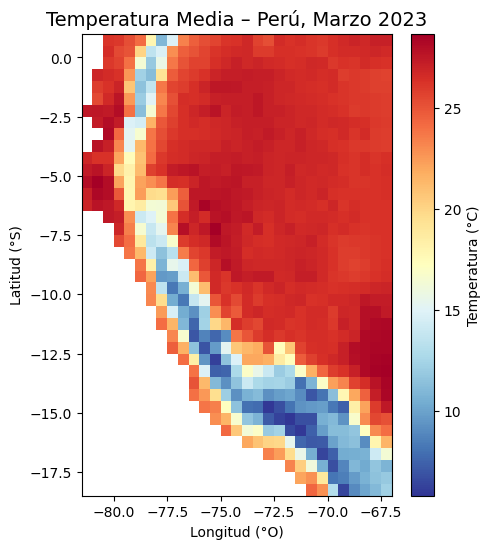

In [ ]:
# Graficar una sola franja temporal – temperatura del Perú en marzo 2023
fig, ax = plt.subplots(figsize=(5, 6))

ds['tmp'].sel(time='2023-03').plot(
    ax=ax,
    cmap='RdYlBu_r',
    cbar_kwargs={'label': 'Temperatura (°C)'}
)

ax.set_title('Temperatura Media – Perú, Marzo 2023', fontsize=14)
ax.set_xlabel('Longitud (°O)')
ax.set_ylabel('Latitud (°S)')

# plt.tight_layout()
plt.show()

In [ ]:
utec_temp

<xarray.DataArray 'tmp' (time: 1488)> Size: 6kB
array([21.800001, 22.9     , 22.1     , ..., 17.      , 18.7     , 19.7     ],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 12kB 1901-01-16 1901-02-15 ... 2024-12-16
    lon      float32 4B -77.25
    lat      float32 4B -12.25
Attributes:
    long_name:                   near-surface temperature
    units:                       degrees Celsius
    correlation_decay_distance:  1200.0

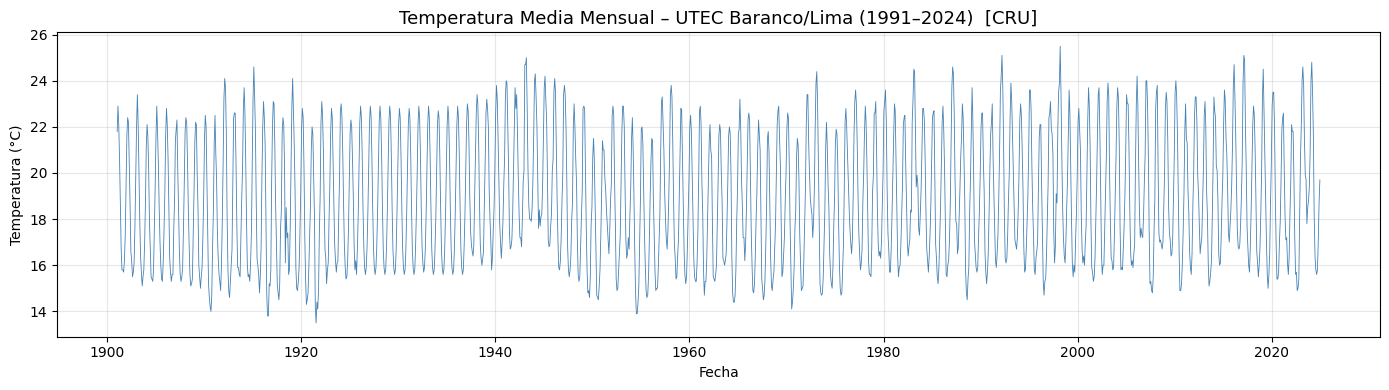

In [ ]:
# Graficar serie de tiempo en Lima
fig, ax = plt.subplots(figsize=(14, 4))

utec_temp.plot(ax=ax, linewidth=0.6, color='steelblue')

ax.set_title('Temperatura Media Mensual – UTEC Baranco/Lima (1991–2024)  [CRU]', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura (°C)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Manejo de valores faltantes

Los datos de CRU solo abarcan áreas terrestres; las celdas de océano y aguas costeras contienen valores NaN (faltantes).

En el subconjunto de CONUS, esto afecta a las áreas costeras oceánicas (Golfo de México, costas del Atlántico y del Pacífico).

In [ ]:
# Comprobar valores faltantes
muestra = ds['tmp'].sel(time='2020-07')
celdas_totales = muestra.size
celdas_faltantes = int(np.isnan(muestra.values).sum())
celdas_válidas = celdas_totales - celdas_faltantes

print(f"Cobertura de datos de julio de 2020 (cuadro delimitador de todo el dataset):")
print(f"Celdas de cuadrícula totales: {celdas_totales:,}")
print(f"Celdas válidas (terrestres): {celdas_válidas:,} ({100*celdas_válidas/celdas_totales:.1f}%)")
print(f"Celdas faltantes (océano/agua): {celdas_faltantes:,} ({100*celdas_faltantes/celdas_totales:.1f}%)")
print(f" → Las celdas oceánicas/costeras dentro del cuadro delimitador tienen NaN valores")

print(f"\nxarray maneja automáticamente los valores NaN en los cálculos:")
print(f"Media terrestre GLOBAL (julio de 2020): {float(muestra.mean()):.2f}°C")

Cobertura de datos de julio de 2020 (cuadro delimitador de todo el dataset):
Celdas de cuadrícula totales: 1,131
Celdas válidas (terrestres): 887 (78.4%)
Celdas faltantes (océano/agua): 244 (21.6%)
 → Las celdas oceánicas/costeras dentro del cuadro delimitador tienen NaN valores

xarray maneja automáticamente los valores NaN en los cálculos:
Media terrestre GLOBAL (julio de 2020): 20.73°C


### 🔬 Ejercicio rápido 1 – Selección e indexado

Usando el dataset `ds`:

1. Selecciona la temperatura media de **Iquitos** (lat ≈ −3.75°, lon ≈ −73.25°) y calcula su media anual del período 2010–2024
2. Extrae la región de los **Andes del Sur** (lat: −12° a −16°, lon: −74° a −70°) y calcula la temperatura media espacial para julio 2020 (obtendras una serie de tiempo para toda la región)
3. ¿Cuántos meses de toda la serie tienen temperatura mínima menor a **20 °**?

In [ ]:
# Tu código aquí

# iquitos_temp = ds['tmp'].sel(???)
# media_iquitos = ???

# andes_sur = ds['tmp'].sel(???)
# temp_media_andes = ???

# temp_media = ds['tmp'].mean(dim=['lat', 'lon'])
# meses_frios = ???

---
## 5. Agregación Espacial y Temporal

### Promedios espaciales: Por qué importa la ponderación por área

Como aprendimos con CRS, las celdas de la cuadrícula a distintas latitudes tienen diferentes áreas. Una media simple trata todas las celdas por igual — **sobreponderando** las celdas más pequeñas (en latitudes más altas).

La corrección: ponderar cada celda por **cos(latitud)**.

Forma de media nacional: (1488,) (un valor por mes)


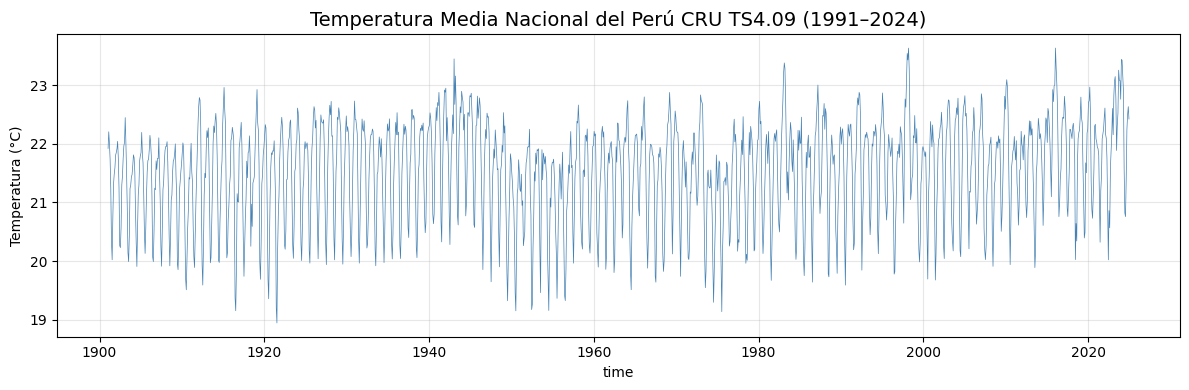

In [ ]:
# Media espacial simple sobre todo el Perú
# Esto da un valor por paso temporal
media_peru = ds['tmp'].mean(dim=['lat', 'lon'])
print(f"Forma de media nacional: {media_peru.shape} (un valor por mes)")

fig, ax = plt.subplots(figsize=(12, 4))
media_peru.plot(ax=ax, linewidth=0.5, color='steelblue')
ax.set_title('Temperatura Media Nacional del Perú CRU TS4.09 (1991–2024)', fontsize=14)
ax.set_ylabel('Temperatura (°C)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# The dataset is already a PERU subset
# (lon: -81.25 to -67.25°W, lat: -18.25°S to 0.75°N)
# No further spatial subsetting needed — use the full dataset directly
peru = ds['tmp']
peru_mean = peru.mean(dim=['lat', 'lon'])
print(f"PERU region shape: {peru.shape}")
print(f"  → {peru.shape[1]} lat cells × {peru.shape[2]} lon cells × {peru.shape[0]} months")

PERU region shape: (1488, 39, 29)
  → 39 lat cells × 29 lon cells × 1488 months


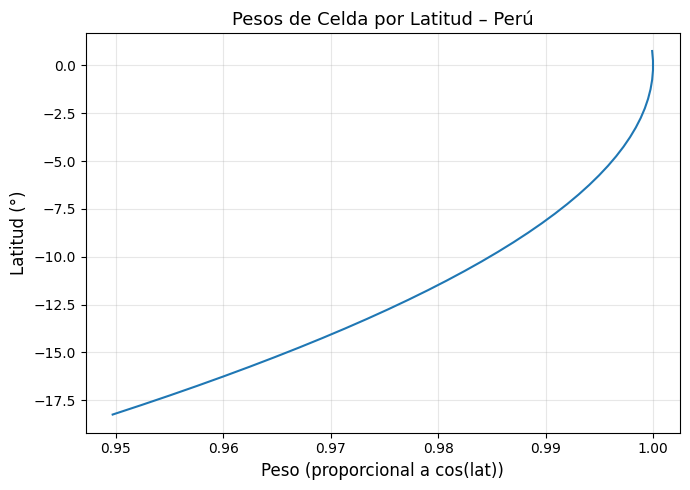

Peso en el ecuador (0°):   1.0000
Peso a 5°S (Pucallpa):     0.9962
Peso a 12°S (Cusco):       0.9781
Peso a 17°S (Tacna):       0.9563
Peso a 60°S :       0.5736
(Diferencias pequeñas porque el Perú está cerca del ecuador)


In [ ]:
# Calcular pesos basados en latitud (ponderación coseno)
pesos = np.cos(np.deg2rad(ds.lat))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(pesos.values, ds.lat.values, markersize=4) #, 'b-o'
ax.set_xlabel('Peso (proporcional a cos(lat))', fontsize=12)
ax.set_ylabel('Latitud (°)', fontsize=12)
ax.set_title('Pesos de Celda por Latitud – Perú', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peso en el ecuador (0°):   {np.cos(np.deg2rad(0)):.4f}")
print(f"Peso a 5°S (Pucallpa):     {np.cos(np.deg2rad(5)):.4f}")
print(f"Peso a 12°S (Cusco):       {np.cos(np.deg2rad(12)):.4f}")
print(f"Peso a 17°S (Tacna):       {np.cos(np.deg2rad(17)):.4f}")
print(f"Peso a 60°S :       {np.cos(np.deg2rad(55)):.4f}")
print("(Diferencias pequeñas porque el Perú está cerca del ecuador)")

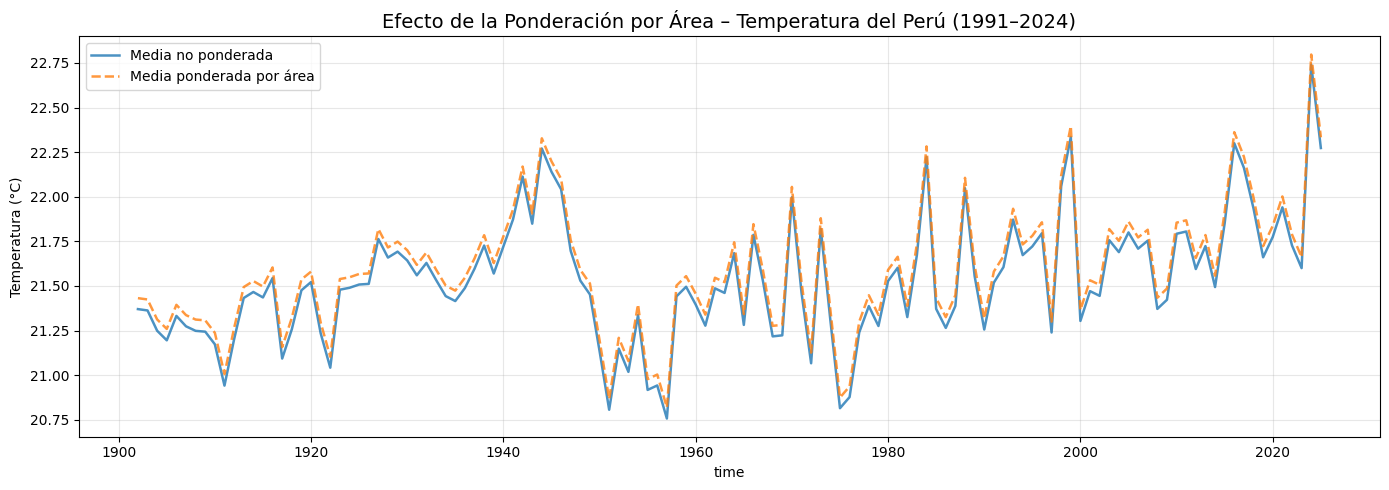

Diferencia media: -0.060°C
La diferencia es pequeña porque el Perú está cerca del ecuador (latitudes bajas).
Para datasets con mayor rango latitudinal (ej. CONUS, global) la diferencia es mayor.


In [ ]:
# Media ponderada vs. no ponderada
media_no_pond = ds['tmp'].mean(dim=['lat', 'lon'])
media_pond    = ds['tmp'].weighted(pesos).mean(dim=['lat', 'lon'])

anual_no_pond = media_no_pond.resample(time='YE').mean()
anual_pond    = media_pond.resample(time='YE').mean()

fig, ax = plt.subplots(figsize=(14, 5))
anual_no_pond.plot(ax=ax, label='Media no ponderada', alpha=0.8, linewidth=1.8)
anual_pond.plot(ax=ax,    label='Media ponderada por área', alpha=0.8, linewidth=1.8,
               linestyle='--')

ax.set_title('Efecto de la Ponderación por Área – Temperatura del Perú (1991–2024)', fontsize=14)
ax.set_ylabel('Temperatura (°C)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

dif = float((anual_no_pond - anual_pond).mean().values)
print(f"Diferencia media: {dif:.3f}°C")
print("La diferencia es pequeña porque el Perú está cerca del ecuador (latitudes bajas).")
print("Para datasets con mayor rango latitudinal (ej. CONUS, global) la diferencia es mayor.")

### 5.1 Agregación temporal

In [ ]:
# Remuestrear datos mensuales a medias anuales
media_anual = ds['tmp'].resample(time='YE').mean()

print(f"Forma original (mensual): {ds['tmp'].shape}")
print(f"Forma media anual: {media_anual.shape}")
print(f"Años: {int(media_anual.time.dt.year.values[0])} a {int(media_anual.time.dt.year.values[-1])}")

Forma original (mensual): (1488, 39, 29)
Forma media anual: (124, 39, 29)
Años: 1901 a 2024


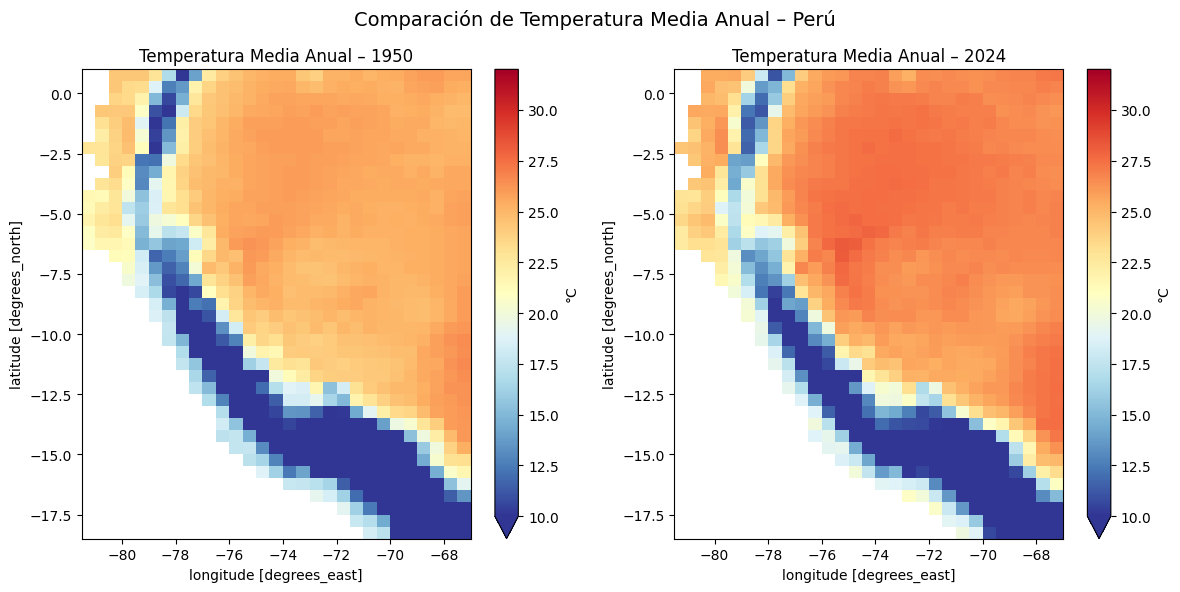

In [ ]:
# Comparar mapas de temperatura: período temprano vs. reciente
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

vmin, vmax = 10, 32

media_anual.sel(time='1950').plot(
    ax=axes[0], cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
    cbar_kwargs={'label': '°C'}
)
axes[0].set_title('Temperatura Media Anual – 1950')

media_anual.sel(time='2024').plot(
    ax=axes[1], cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
    cbar_kwargs={'label': '°C'}
)
axes[1].set_title('Temperatura Media Anual – 2024')

plt.suptitle('Comparación de Temperatura Media Anual – Perú', fontsize=14)
plt.tight_layout()
plt.show()

---
## 7. Mapas de Calidad de Publicación con Cartopy

Hasta ahora hemos usado el `.plot()` integrado de xarray, que produce mapas rápidos pero sin contexto geográfico. **Cartopy** nos permite crear mapas con:
- Costas, fronteras de países y departamentos
- Elección de proyección cartográfica
- Cuadrículas con etiquetas
- Estilo cartográfico profesional

### Receta básica

```python
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proyeccion = ccrs.PlateCarree()             # elegir proyección
fig, ax = plt.subplots(subplot_kw={'projection': proyeccion})
datos.plot(ax=ax, transform=ccrs.PlateCarree())  # datos en lat/lon
ax.add_feature(cfeature.BORDERS)               # agregar elementos del mapa
ax.add_feature(cfeature.COASTLINE)
```

**Idea clave:** Los **datos** viven en PlateCarree (lat/lon), y cartopy los **reproyecta** sobre la marcha en la proyección que uses en los ejes.

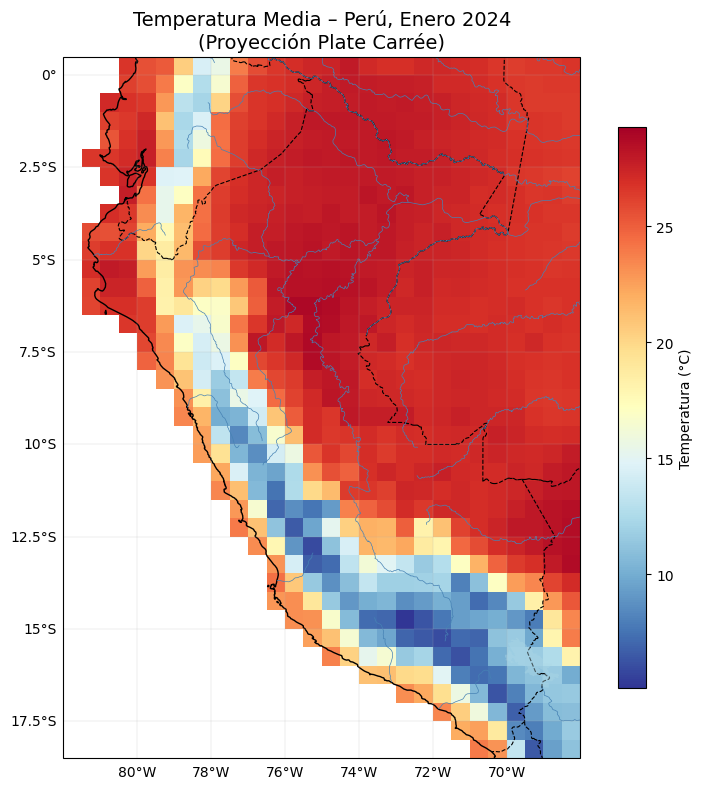

Comparado con el .plot() simple de xarray — las costas, ríos y fronteras
dan mucho mejor contexto geográfico.


In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ── Mapa básico: temperatura del Perú en enero 2024 con elementos geográficos ──
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Graficar datos (transform indica el CRS nativo de los datos)
ds['tmp'].sel(time='2024-01').plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    cbar_kwargs={'label': 'Temperatura (°C)', 'shrink': 0.8}
)

# Agregar elementos geográficos
ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, linestyle='--')
ax.add_feature(cfeature.LAKES,   alpha=0.4, facecolor='lightblue')
ax.add_feature(cfeature.RIVERS,  linewidth=0.5, edgecolor='steelblue')

# Cuadrículas
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels   = False
gl.right_labels = False

# Extensión del mapa
ax.set_extent([-82, -68, -18.5, 0.5], crs=ccrs.PlateCarree())

ax.set_title('Temperatura Media – Perú, Enero 2024\n(Proyección Plate Carrée)', fontsize=14)

plt.tight_layout()
plt.show()

print("Comparado con el .plot() simple de xarray — las costas, ríos y fronteras")
print("dan mucho mejor contexto geográfico.")

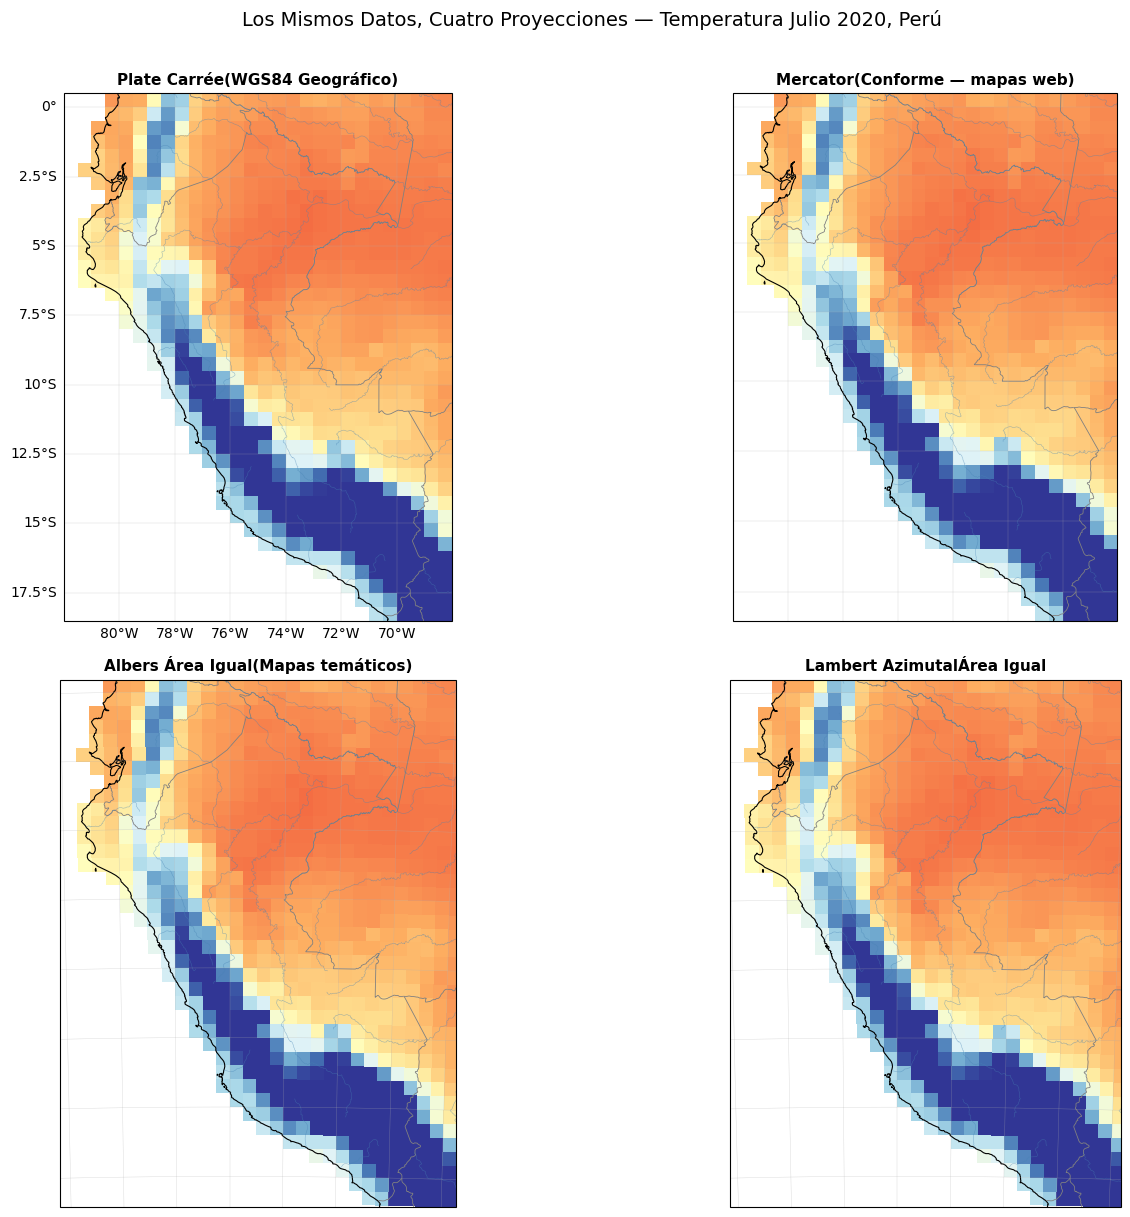

Plate Carrée / WGS84:    cuadrícula lat/lon simple — la más usada en datos climáticos
Mercator:                preserva ángulos y formas — estándar en mapas web (Google Maps)
Albers Área Igual:       preserva áreas — ideal para mapas temáticos y de densidad
Lambert Azimutal A.I.:   preserva áreas desde un punto central — buena para regiones compactas


In [ ]:
# # --- Comparación: cuatro proyecciones con datos del Perú ---

# jul_2020 = ds['tmp'].sel(time='2020-07')

# proj_list = [
#     ('Plate Carrée(WGS84 Geográfico)',
#      ccrs.PlateCarree()),
#     ('Mercator(Conforme — mapas web)',
#      ccrs.Mercator(min_latitude=-25, max_latitude=5)),
#     ('Albers Área Igual(Mapas temáticos)',
#      ccrs.AlbersEqualArea(central_longitude=-76, central_latitude=-10,
#                           standard_parallels=(-5, -18))),
#     ('Lambert AzimutalÁrea Igual',
#      ccrs.LambertAzimuthalEqualArea(central_longitude=-76, central_latitude=-10)),
# ]

# fig = plt.figure(figsize=(16, 12))

# for i, (name, proj) in enumerate(proj_list):
#     ax = fig.add_subplot(2, 2, i + 1, projection=proj)

#     try:
#         ax.set_extent([-82, -68, -18.5, 0.5], crs=ccrs.PlateCarree())
#     except Exception:
#         ax.set_global()

#     jul_2020.plot(
#         ax=ax, transform=ccrs.PlateCarree(),
#         cmap='RdYlBu_r', add_colorbar=False, vmin=8, vmax=32
#     )

#     ax.coastlines(linewidth=0.8)
#     ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='gray')
#     ax.add_feature(cfeature.RIVERS, linewidth=0.4, edgecolor='steelblue', alpha=0.5)

#     gl = ax.gridlines(draw_labels=(i == 0), linewidth=0.3, alpha=0.5)
#     gl.top_labels = False
#     gl.right_labels = False

#     ax.set_title(name, fontsize=11, fontweight='bold')

# # Barra de color compartida
# sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=plt.Normalize(vmin=8, vmax=32))
# sm.set_array([])
# #fig.colorbar(sm, ax=fig.axes, shrink=0.6, label='Temperatura (°C)', pad=0.02)

# plt.suptitle('Los Mismos Datos, Cuatro Proyecciones — Temperatura Julio 2020, Perú',
#              fontsize=14, y=1.01)
# plt.tight_layout()
# plt.show()

# print("Plate Carrée / WGS84:    cuadrícula lat/lon simple — la más usada en datos climáticos")
# print("Mercator:                preserva ángulos y formas — estándar en mapas web (Google Maps)")
# print("Albers Área Igual:       preserva áreas — ideal para mapas temáticos y de densidad")
# print("Lambert Azimutal A.I.:   preserva áreas desde un punto central — buena para regiones compactas")


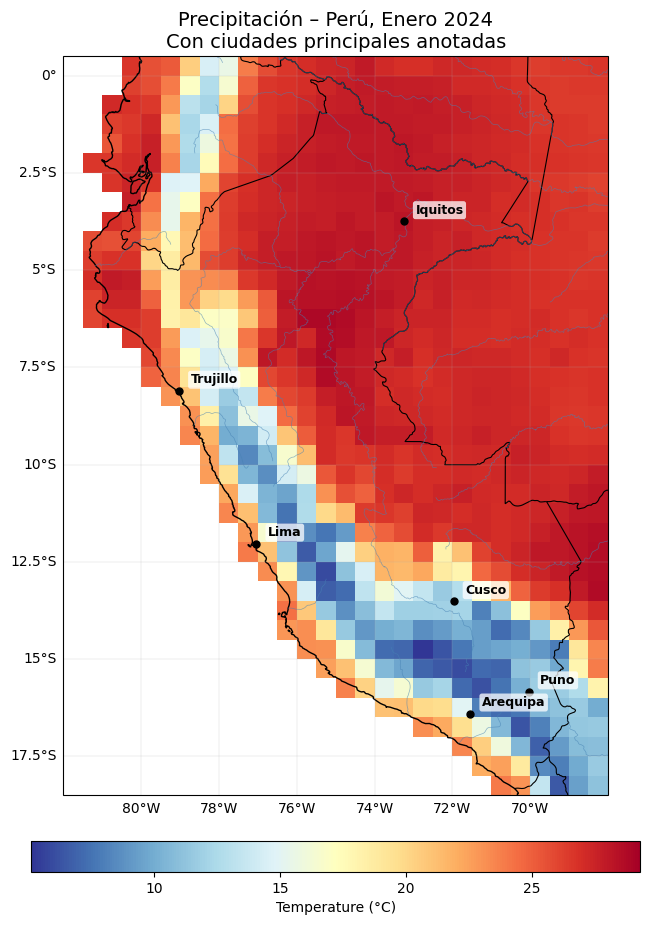

In [ ]:
# ── Mapa anotado: marcar ciudades peruanas principales ──
ciudades_mapa = {
    'Lima':     (-77.04, -12.04),
    'Cusco':    (-71.97, -13.52),
    'Iquitos':  (-73.25,  -3.75),
    'Arequipa': (-71.54, -16.41),
    'Trujillo': (-79.03,  -8.11),
    'Puno':     (-70.04, -15.84),
}

fig, ax = plt.subplots(
    figsize=(9, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
ax.set_extent([-82, -68, -18.5, 0.5], crs=ccrs.PlateCarree())

# Precipitación de enero 2024
ds['tmp'].sel(time='2024-01').plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    # cbar_kwargs={'label': 'Temperatura (°C)', 'shrink': 0.8}
    cbar_kwargs={'label': 'Temperature (°C)', 'shrink': 0.7, 'orientation': 'horizontal', 'pad': 0.05}

)

ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.RIVERS,  linewidth=0.5, edgecolor='steelblue', alpha=0.6)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False; gl.right_labels = False

# Marcar ciudades
for nombre, (lon, lat) in ciudades_mapa.items():
    ax.plot(lon, lat, 'ko', markersize=5, transform=ccrs.PlateCarree())
    ax.text(lon + 0.3, lat + 0.2, nombre, fontsize=9, fontweight='bold',
            transform=ccrs.PlateCarree(),
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'))

ax.set_title('Precipitación – Perú, Enero 2024\nCon ciudades principales anotadas', fontsize=14)
plt.tight_layout()
plt.show()

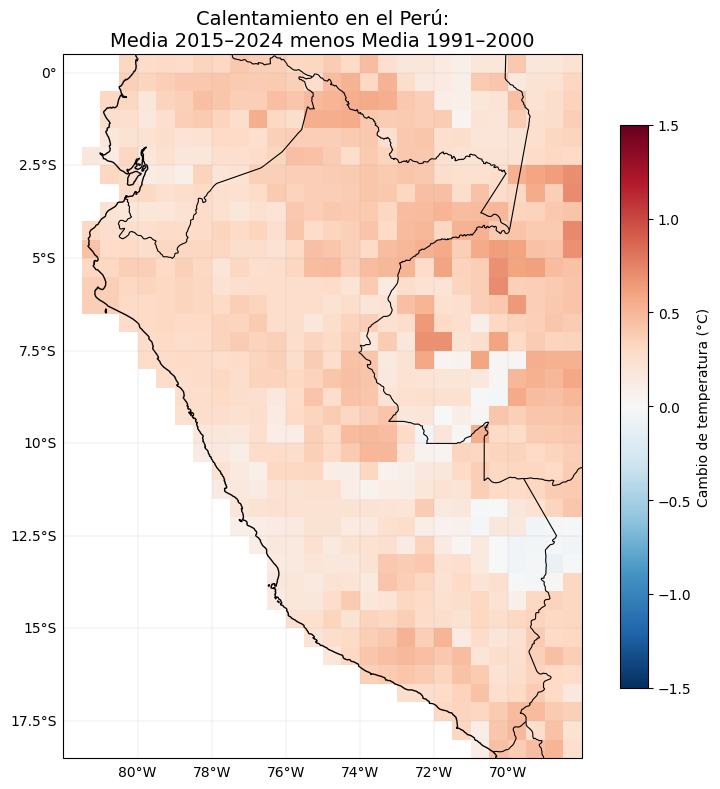

Calentamiento medio nacional: 0.30°C
Máximo calentamiento (celda): 0.72°C
Rojo = calentamiento, Azul = enfriamiento


In [ ]:
# ── Mapa de calentamiento: décadas recientes vs. período base temprano ──
periodo_1991_2000 = ds['tmp'].sel(time=slice('1991', '2000')).mean(dim='time')
periodo_2015_2024 = ds['tmp'].sel(time=slice('2015', '2024')).mean(dim='time')
calentamiento = periodo_2015_2024 - periodo_1991_2000

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-82, -68, -18.5, 0.5], crs=ccrs.PlateCarree())

calentamiento.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r', center=0,
    vmin=-1.5, vmax=1.5,
    cbar_kwargs={'label': 'Cambio de temperatura (°C)', 'shrink': 0.8}
)

ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False; gl.right_labels = False

ax.set_title('Calentamiento en el Perú:\nMedia 2015–2024 menos Media 1991–2000', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Calentamiento medio nacional: {float(calentamiento.mean()):.2f}°C")
print(f"Máximo calentamiento (celda): {float(calentamiento.max()):.2f}°C")
print("Rojo = calentamiento, Azul = enfriamiento")

### Referencia rápida de Cartopy

| Elemento | Código |
|----------|--------|
| Costas | `ax.coastlines()` |
| Fronteras de países | `ax.add_feature(cfeature.BORDERS)` |
| Lagos | `ax.add_feature(cfeature.LAKES)` |
| Ríos | `ax.add_feature(cfeature.RIVERS)` |
| Relleno de océano | `ax.add_feature(cfeature.OCEAN)` |
| Cuadrículas + etiquetas | `ax.gridlines(draw_labels=True)` |
| Establecer extensión del mapa | `ax.set_extent([O, E, S, N], crs=ccrs.PlateCarree())` |

| Proyección | Mejor para |
|------------|------------|
| `ccrs.PlateCarree()` | Exploración rápida, mapas regionales |
| `ccrs.Mercator()` | Navegación, mapas web |
| `ccrs.AlbersEqualArea(...)` | Mapas temáticos / densidad (preserva áreas) |
| `ccrs.Orthographic(...)` | Vista de globo |

**Regla clave:** Siempre pasa `transform=ccrs.PlateCarree()` al graficar datos lat/lon — esto le dice a cartopy el CRS nativo de los datos para reprojectarlos correctamente.

---
## 8. Anomalías Climáticas

### ¿Qué es una anomalía?

Una **anomalía climática** es la desviación respecto a un período de referencia "normal":

$$\text{Anomalía} = \text{Observado} - \text{Climatología}$$

**Climatología:** La media a largo plazo (típicamente 30 años, ej. 1991–2020)

### ¿Por qué usar anomalías?

1. **Elimina el ciclo estacional:** Más fácil ver tendencias y eventos inusuales
2. **Comparable entre lugares:** Una anomalía de +2°C significa lo mismo en Iquitos y en Cusco
3. **Estándar en climatología:** Requerido para comparar observaciones con modelos climáticos

### Períodos de referencia estándar

- **1991–2020:** Estándar actual de la OMM (Organización Meteorológica Mundial)
- **1961–1990:** Anterior estándar de la OMM
- **1981–2010:** Usado por SENAMHI en muchos productos
- **Pre-industrial (1850–1900):** Usado para los objetivos del Acuerdo de París

In [ ]:
# Paso 1: Definir el período de referencia (1991–2020)
referencia = ds['tmp'].sel(time=slice('1991', '2020'))
print(f"Período de referencia: 1991–2020")
print(f"  Meses en referencia: {len(referencia.time)}")
print(f"  Años: {len(referencia.time)//12}")

Período de referencia: 1991–2020
  Meses en referencia: 360
  Años: 30


In [ ]:
# Paso 2: Calcular climatología mensual
# Promedio de cada enero, febrero, etc. sobre el período de referencia
climatologia = referencia.groupby('time.month').mean(dim='time')
print(f"Forma de la climatología: {climatologia.shape}")
print(f"  → 12 meses × {climatologia.shape[1]} lat × {climatologia.shape[2]} lon")

Forma de la climatología: (12, 39, 29)
  → 12 meses × 39 lat × 29 lon


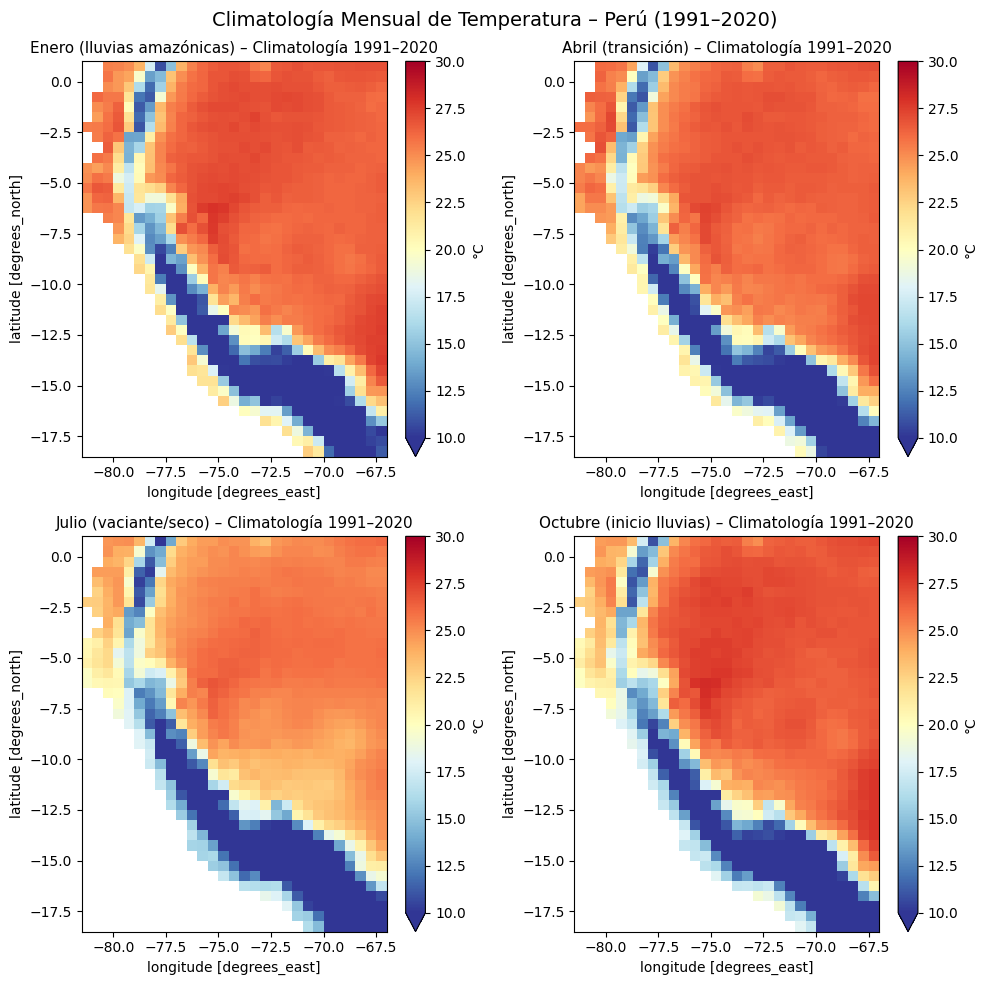

In [ ]:
# Visualizar la climatología para distintos meses
fig, ejes = plt.subplots(2, 2, figsize=(10, 10))

meses_vis  = [1, 4, 7, 10]
nombres_mes = ['Enero (lluvias amazónicas)', 'Abril (transición)',
               'Julio (vaciante/seco)', 'Octubre (inicio lluvias)']

for ax, mes, nombre in zip(ejes.flat, meses_vis, nombres_mes):
    climatologia.sel(month=mes).plot(
        ax=ax, cmap='RdYlBu_r',
        vmin=10, vmax=30,
        cbar_kwargs={'label': '°C'}
    )
    ax.set_title(f'{nombre} – Climatología 1991–2020', fontsize=11)

plt.suptitle('Climatología Mensual de Temperatura – Perú (1991–2020)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Paso 3: Calcular anomalías
# Restar la climatología mensual apropiada de cada mes
anomalia = ds['tmp'].groupby('time.month') - climatologia
print(f"Forma de la anomalía: {anomalia.shape}")
print(f"Rango de anomalías: {float(anomalia.min()):.1f}°C a {float(anomalia.max()):.1f}°C")

Forma de la anomalía: (1488, 39, 29)
Rango de anomalías: -4.3°C a 4.2°C


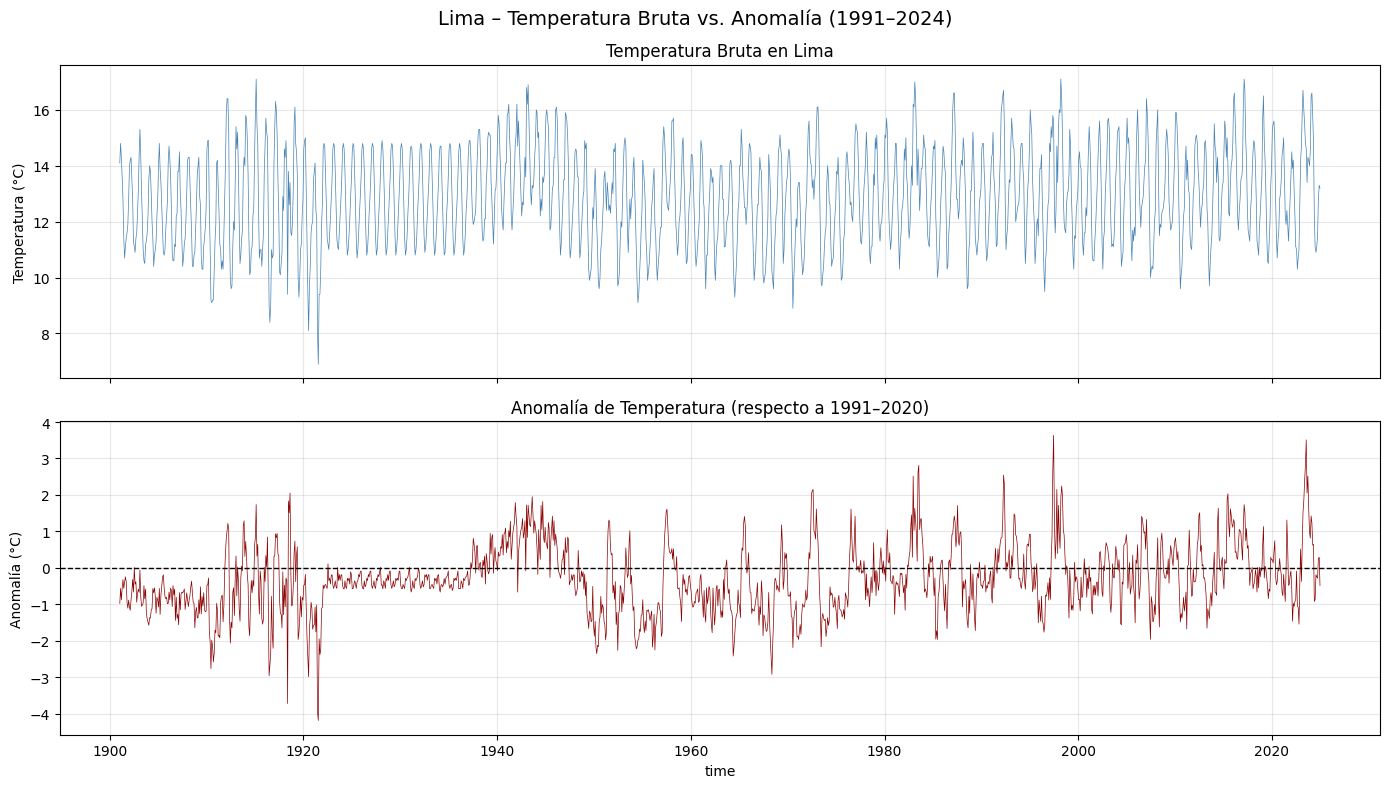

Las anomalías eliminan el ciclo estacional, haciendo visibles las tendencias a largo plazo.


In [ ]:
# Comparar: temperatura bruta vs. anomalía en Lima
fig, ejes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

lima_bruta = ds['tmp'].sel(lat=-12.0, lon=-77.0, method='nearest')
lima_anom  = anomalia.sel(lat=-12.0, lon=-77.0, method='nearest')

# Temperatura bruta
lima_bruta.plot(ax=ejes[0], linewidth=0.5, color='steelblue')
ejes[0].set_title('Temperatura Bruta en Lima', fontsize=12)
ejes[0].set_ylabel('Temperatura (°C)')
ejes[0].set_xlabel('')
ejes[0].grid(True, alpha=0.3)

# Anomalía
lima_anom.plot(ax=ejes[1], linewidth=0.5, color='darkred')
ejes[1].axhline(0, color='black', linestyle='--', linewidth=1)
ejes[1].set_title('Anomalía de Temperatura (respecto a 1991–2020)', fontsize=12)
ejes[1].set_ylabel('Anomalía (°C)')
ejes[1].grid(True, alpha=0.3)

plt.suptitle('Lima – Temperatura Bruta vs. Anomalía (1991–2024)', fontsize=14)
plt.tight_layout()
plt.show()

print("Las anomalías eliminan el ciclo estacional, haciendo visibles las tendencias a largo plazo.")

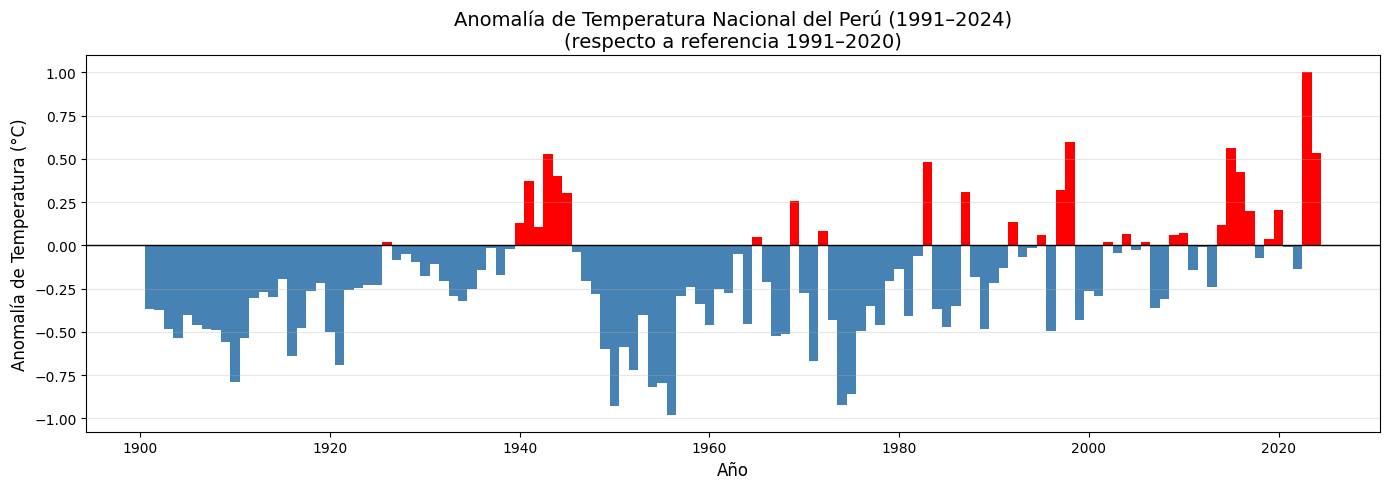

Anomalía media (1991–2000): -0.03°C
Anomalía media (2015–2024): +0.28°C
Calentamiento: +0.30°C


In [ ]:
# Anomalía de temperatura nacional del Perú (ponderada por área)
anomalia_nacional = anomalia.weighted(pesos).mean(dim=['lat', 'lon'])
anomalia_anual    = anomalia_nacional.resample(time='YE').mean()

fig, ax = plt.subplots(figsize=(14, 5))

anios  = anomalia_anual.time.dt.year.values
valores = anomalia_anual.values

colores = ['steelblue' if v < 0 else 'red' for v in valores]
ax.bar(anios, valores, color=colores, edgecolor='none', width=1)
ax.axhline(0, color='black', linewidth=1)

ax.set_xlabel('Año', fontsize=12)
ax.set_ylabel('Anomalía de Temperatura (°C)', fontsize=12)
ax.set_title('Anomalía de Temperatura Nacional del Perú (1991–2024)\n(respecto a referencia 1991–2020)', fontsize=14)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

temprano = float(anomalia_anual.sel(time=slice('1991', '2000')).mean().values)
reciente = float(anomalia_anual.sel(time=slice('2015', '2024')).mean().values)
print(f"Anomalía media (1991–2000): {temprano:+.2f}°C")
print(f"Anomalía media (2015–2024): {reciente:+.2f}°C")
print(f"Calentamiento: {reciente - temprano:+.2f}°C")

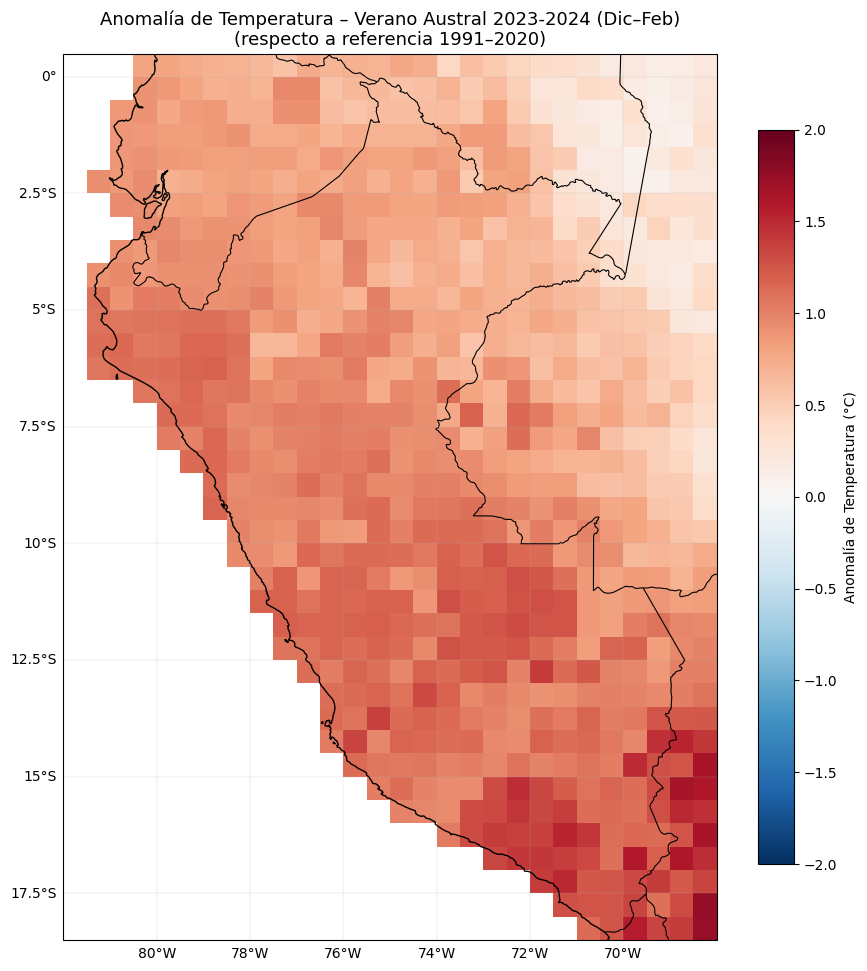

In [ ]:
# Mapa de anomalía: verano austral 2023-2024 (Dic-Feb) con cartopy
anom_verano = anomalia.sel(time=slice('2023-12', '2024-02')).mean(dim='time')

fig, ax = plt.subplots(figsize=(9, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-82, -68, -18.5, 0.5], crs=ccrs.PlateCarree())

anom_verano.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r', center=0,
    vmin=-2, vmax=2,
    cbar_kwargs={'label': 'Anomalía de Temperatura (°C)', 'shrink': 0.8}
)

ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False; gl.right_labels = False

ax.set_title('Anomalía de Temperatura – Verano Austral 2023-2024 (Dic–Feb)\n(respecto a referencia 1991–2020)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Ejercicio

**Tarea:** Analizar la anomalía de temperatura en la Amazonia peruana durante el evento El Niño 2015–2016.

1. Extrae la región amazónica del Perú (lat: −2° a −8°, lon: −76° a −70°) de los datos de anomalía
2. Selecciona el período de El Niño 2015–2016 (julio 2015 a junio 2016)
3. Calcula la anomalía media ponderada por área para esa región y período
4. Crea un mapa con cartopy mostrando la anomalía espacial durante ese período
5. Reporta si el período fue más cálido o más frío que lo normal

In [ ]:
# Tu código aquí

# 1. Región amazónica
# amazonia_anom = anomalia.sel(???)

# 2. Período El Niño
# nino_period = amazonia_anom.sel(time=slice(???))

# 3. Anomalía media ponderada
# pesos_amaz = np.cos(np.deg2rad(amazonia_anom.lat))
# anomalia_media = nino_period.weighted(pesos_amaz).mean(dim=['lat', 'lon', 'time'])

# 4. Mapa con cartopy
# fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
# ...

# 5. Reporte
# print(f"Anomalía durante El Niño 2015-2016 en Amazonia: {float(anomalia_media):+.2f}°C")

In [ ]:
# Plotear las Tmin de PISCO
# ds_pisco.plot()

---
## Resumen

### Conceptos clave

| Concepto | Descripción |
|----------|-------------|
| Datos gridded | Campos ambientales continuos en cuadrículas regulares lat/lon/tiempo |
| CRS | Los sistemas de referencia de coordenadas definen cómo las coordenadas se relacionan con la Tierra; las proyecciones causan distorsión |
| NetCDF | Formato de archivo auto-descriptivo estándar para datos climáticos/ambientales |
| xarray | Librería Python para arreglos multidimensionales etiquetados |
| Ponderación por área | Se debe ponderar por cos(latitud) para promedios espaciales precisos |
| Cartopy | Librería para mapas de calidad de publicación con costas, fronteras y proyecciones |
| Climatología | Media a largo plazo (típicamente 30 años) para cada mes/estación |
| Anomalía | Desviación respecto a la climatología: Observado − Normal |

### Operaciones clave de xarray

| Tarea | Método |
|-------|--------|
| Cargar NetCDF | `xr.open_dataset("archivo.nc")` |
| Seleccionar por valor | `.sel(lat=-13, lon=-72)` |
| Seleccionar el más cercano | `.sel(lat=-13, method='nearest')` |
| Segmentar rango | `.sel(lat=slice(-2, -8))` |
| Media sobre dimensión | `.mean(dim='time')` o `.mean(dim=['lat', 'lon'])` |
| Media ponderada | `.weighted(pesos).mean(dim=...)` |
| Remuestrear tiempo | `.resample(time='YE').mean()` |
| Agrupar por mes | `.groupby('time.month')` |

### Operaciones clave de Cartopy

| Tarea | Código |
|-------|--------|
| Crear ejes de mapa | `plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})` |
| Graficar datos lat/lon | `datos.plot(ax=ax, transform=ccrs.PlateCarree())` |
| Agregar costas | `ax.coastlines()` |
| Agregar fronteras | `ax.add_feature(cfeature.BORDERS)` |
| Establecer extensión del mapa | `ax.set_extent([O, E, S, N], crs=ccrs.PlateCarree())` |
| Agregar cuadrículas | `ax.gridlines(draw_labels=True)` |

### Próxima clase

**Clase 12:** Teledetección Satelital y Análisis Ráster — trabajar con imágenes Landsat/Sentinel, índices espectrales y análisis de cobertura del suelo.

---
## Soluciones

In [ ]:
# Solución Ejercicio rápido 1 – Selección e indexado

# 1. Temperatura media de Iquitos 2010–2024
iquitos_temp = ds['tmp'].sel(lat=-3.75, lon=-73.25, method='nearest')
media_iquitos = float(iquitos_temp.sel(time=slice('2010', '2024')).mean())
print(f"Temperatura media Iquitos (2010–2024): {media_iquitos:.2f}°C")

# 2. Temperatura media Andes del Sur – julio 2020
andes_sur = ds['tmp'].sel(lat=slice(-12.0, -16.0), lon=slice(-74.0, -70.0))
temp_media_andes = float(andes_sur.sel(time='2020-07').mean())
print(f"Temperatura media Andes del Sur – julio 2020: {temp_media_andes:.2f}°C")

# 3. Meses con temperatura media nacional < 20 °C
temp_media = ds['tmp'].mean(dim=['lat', 'lon'])
meses_frios = int((temp_media < 20).sum())
print(f"Meses con temperatura media nacional < 20 °C: {meses_frios}")

Temperatura media Iquitos (2010–2024): 27.24°C
Temperatura media Andes del Sur – julio 2020: nan°C
Meses con temperatura media nacional < 20 °C: 81


Meses El Niño seleccionados: 12
Anomalia: <xarray.DataArray 'tmp' (lat: 12, lon: 12)> Size: 576B
array([[0.76305723, 0.6922226 , 0.61138964, 0.7180559 , 0.7063899 ,
        0.4911108 , 0.6555564 , 0.81388855, 0.5480549 , 0.5155571 ,
        0.76583433, 0.5338904 ],
       [0.7827789 , 0.67194444, 0.61277705, 0.655556  , 0.55305606,
        0.5949996 , 0.48972273, 0.95777816, 0.937778  , 0.5847227 ,
        0.570278  , 0.80027753],
       [0.6280548 , 0.58555526, 0.6116667 , 0.6311102 , 0.67305547,
        0.6455558 , 0.59333324, 0.8961112 , 0.6011119 , 0.59166735,
        0.51027745, 0.6633342 ],
       [0.6247228 , 0.66805536, 0.6600008 , 0.69000024, 0.53888875,
        0.5094455 , 0.81500196, 0.8144457 , 0.59055614, 0.6133334 ,
        0.6466668 , 0.5830563 ],
       [0.65361243, 0.63250035, 0.5869446 , 0.5938883 , 0.68305665,
        0.49194384, 0.6611123 , 0.5216656 , 0.56916714, 0.6799992 ,
        0.66388816, 0.80638885],
       [0.66361046, 0.903611  , 0.8908337 , 0.6380563 , 0.

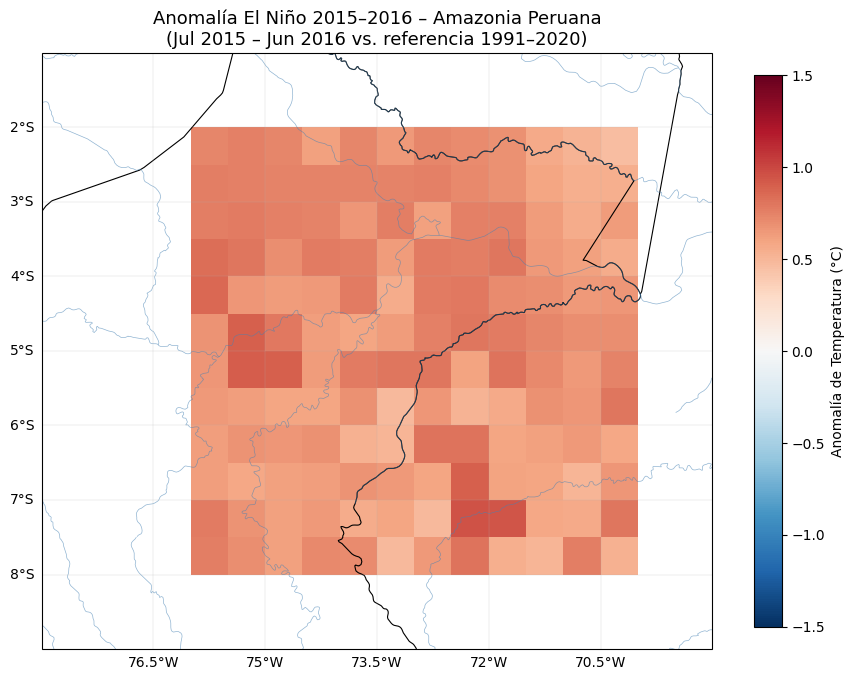


Anomalía media El Niño 2015-2016 – Amazonia: +0.68°C
→ La Amazonia peruana estuvo 0.68°C MÁS CÁLIDA de lo normal durante El Niño 2015-2016.


In [ ]:
# Solución Ejercicio integrador – Anomalía El Niño 2015-2016 en Amazonia

# 1. Región amazónica
amazonia_anom = anomalia.sel(
    lat=slice(-8.0, -2.0), # Recuerden de menor a mayor
    lon=slice(-76.0, -70.0)
)

# 2. Período El Niño
periodo_nino = amazonia_anom.sel(time=slice('2015-07', '2016-06'))
print(f"Meses El Niño seleccionados: {len(periodo_nino.time)}")

# 3. Anomalía media ponderada
pesos_amaz = np.cos(np.deg2rad(amazonia_anom.lat))
anomalia_media = float(
    periodo_nino.weighted(pesos_amaz).mean(dim=['lat', 'lon', 'time'])
)

# 4. Mapa con cartopy
anom_mapa = periodo_nino.mean(dim='time')
print(f"Anomalia: {anom_mapa}")

fig, ax = plt.subplots(figsize=(9, 7), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-78, -69, -9, -1], crs=ccrs.PlateCarree())

anom_mapa.plot(
    ax=ax, transform=ccrs.PlateCarree(),
    cmap='RdBu_r', center=0, vmin=-1.5, vmax=1.5,
    cbar_kwargs={'label': 'Anomalía de Temperatura (°C)', 'shrink': 0.85}
)
ax.coastlines(linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='steelblue', alpha=0.6)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False; gl.right_labels = False
ax.set_title('Anomalía El Niño 2015–2016 – Amazonia Peruana\n(Jul 2015 – Jun 2016 vs. referencia 1991–2020)',
             fontsize=13)
plt.tight_layout()
plt.show()

# 5. Reporte
print(f"\nAnomalía media El Niño 2015-2016 – Amazonia: {anomalia_media:+.2f}°C")
if anomalia_media > 0:
    print(f"→ La Amazonia peruana estuvo {abs(anomalia_media):.2f}°C MÁS CÁLIDA de lo normal durante El Niño 2015-2016.")
else:
    print(f"→ La Amazonia peruana estuvo {abs(anomalia_media):.2f}°C MÁS FRÍA de lo normal.")